In [ ]:
# Install TensorFlow
!pip install -q tensorflow

In [ ]:
# Core utilities
import os
import pandas as pd
import numpy as np

# Image handling
from PIL import Image

# Kaggle dataset downloader
!pip install -q kagglehub


In [ ]:
import kagglehub

# Download dataset
dataset_path = kagglehub.dataset_download(
    "aryansinghal10/alzheimers-multiclass-dataset-equal-and-augmented"
)

print("Dataset downloaded to:")
print(dataset_path)


Using Colab cache for faster access to the 'alzheimers-multiclass-dataset-equal-and-augmented' dataset.
Dataset downloaded to:
/kaggle/input/alzheimers-multiclass-dataset-equal-and-augmented


In [ ]:
# List root directory contents
os.listdir(dataset_path)


['combined_images']

In [ ]:
# Main image folder
DATA_DIR = os.path.join(dataset_path, "combined_images")

# Class folders (exactly as provided)
CLASSES = [
    "MildDemented",
    "ModerateDemented",
    "NonDemented",
    "VeryMildDemented"
]

# Verify each class folder exists
for cls in CLASSES:
    class_path = os.path.join(DATA_DIR, cls)
    print(cls, "->", "Found" if os.path.exists(class_path) else "Missing")


MildDemented -> Found
ModerateDemented -> Found
NonDemented -> Found
VeryMildDemented -> Found


In [ ]:
## Load image paths and labels into a DataFrame

data = []

for label in CLASSES:
    class_folder = os.path.join(DATA_DIR, label)

    for img_name in os.listdir(class_folder):
        img_path = os.path.join(class_folder, img_name)

        # Ensure valid image files only
        if img_name.lower().endswith((".jpg", ".jpeg", ".png")):
            data.append({
                "image_path": img_path,
                "label": label
            })

# Create DataFrame
df = pd.DataFrame(data)

print("Total images loaded:", len(df))
df.head()


Total images loaded: 44000


,image_path,label
0,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented
1,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented
2,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented
3,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented
4,/kaggle/input/alzheimers-multiclass-dataset-eq...,MildDemented


In [ ]:
df["label"].value_counts()


,count
label,
NonDemented,12800
VeryMildDemented,11200
ModerateDemented,10000
MildDemented,10000


Text(0.5, 1.0, 'Class: MildDemented')

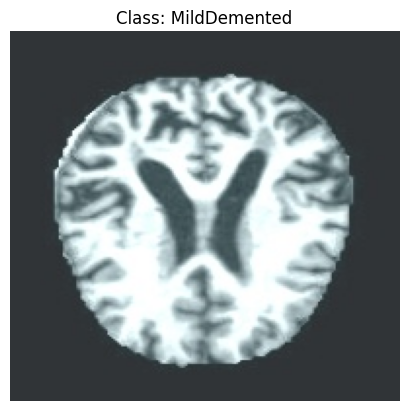

In [ ]:
## Sanity check – load and display one image
import matplotlib.pyplot as plt

sample_row = df.sample(1).iloc[0]
img = Image.open(sample_row["image_path"])

plt.imshow(img)
plt.axis("off")
plt.title(f"Class: {sample_row['label']}")


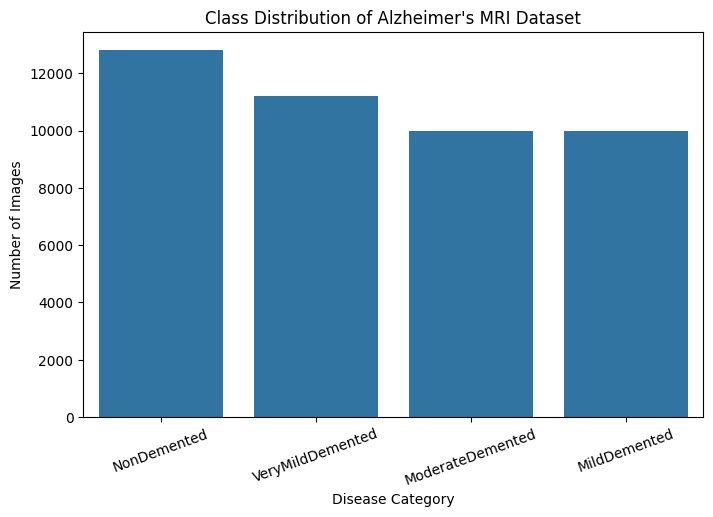

In [ ]:
## Class Distribution Plot

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.countplot(data=df, x="label", order=df["label"].value_counts().index)
plt.title("Class Distribution of Alzheimer's MRI Dataset")
plt.xlabel("Disease Category")
plt.ylabel("Number of Images")
plt.xticks(rotation=20)
plt.show()


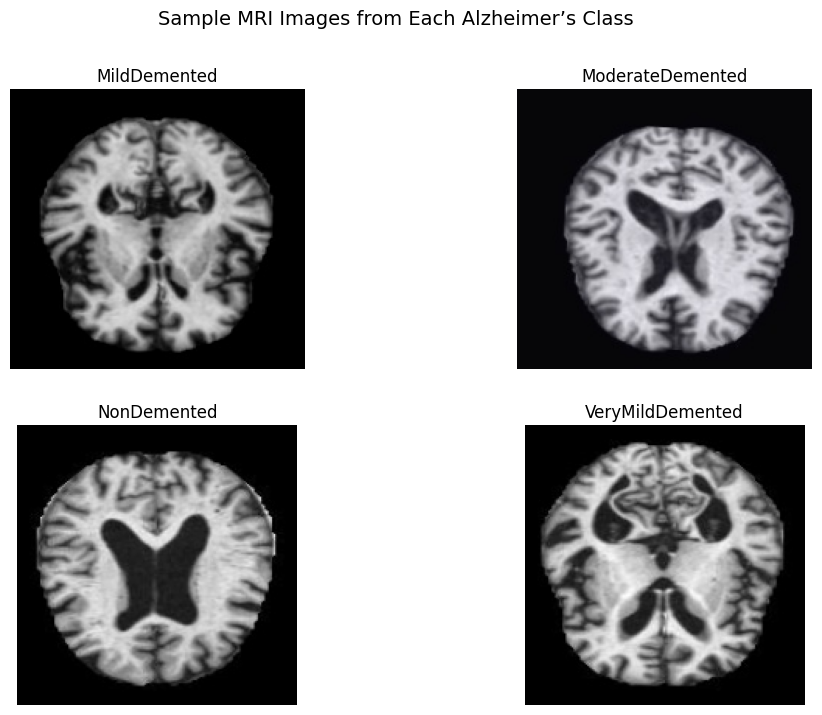

In [ ]:
## Sample MRI Images from Each Class

plt.figure(figsize=(12,8))

for i, label in enumerate(CLASSES):
    sample_img = df[df["label"] == label].sample(1)["image_path"].values[0]
    img = Image.open(sample_img)

    plt.subplot(2, 2, i+1)
    plt.imshow(img)
    plt.axis("off")
    plt.title(label)

plt.suptitle("Sample MRI Images from Each Alzheimer’s Class", fontsize=14)
plt.show()


# **IMAGE PREPROCESSING**

Sampling balanced dataset (5000 images total)...
Final image shape: (5000, 128, 128, 1)
Final label count: 5000

Encoded Classes:
0 -> MildDemented
1 -> ModerateDemented
2 -> NonDemented
3 -> VeryMildDemented

Train size: 2500
Test size: 2500


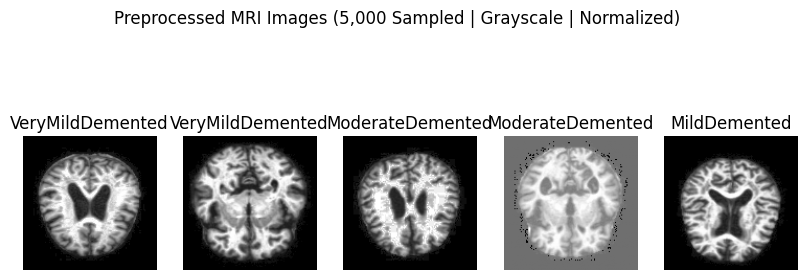

In [ ]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

IMG_SIZE = 128
SAMPLES_PER_CLASS = 1250  # 1250 x 4 = 5000 images

images = []
labels = []

print("Sampling balanced dataset (5000 images total)...")

for cls in CLASSES:
    class_df = df[df["label"] == cls].sample(
        SAMPLES_PER_CLASS, random_state=42
    )

    for path in class_df["image_path"]:
        img = cv2.imread(path)
        img = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)      # Grayscale
        img = cv2.resize(img, (IMG_SIZE, IMG_SIZE))
        img = cv2.equalizeHist(img)                      # Contrast enhancement
        img = img / 255.0                                # Normalization

        images.append(img)
        labels.append(cls)

images = np.array(images)
labels = np.array(labels)

# Add channel dimension for CNN
images = images.reshape(-1, IMG_SIZE, IMG_SIZE, 1)

print("Final image shape:", images.shape)
print("Final label count:", len(labels))

# Encode labels
le = LabelEncoder()
labels_encoded = le.fit_transform(labels)

print("\nEncoded Classes:")
for i, c in enumerate(le.classes_):
    print(i, "->", c)

# 50/50 Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(
    images,
    labels_encoded,
    test_size=0.5,
    random_state=42,
    stratify=labels_encoded
)

print("\nTrain size:", X_train.shape[0])
print("Test size:", X_test.shape[0])


# VISUALIZATION


plt.figure(figsize=(10,4))
for i in range(5):
    plt.subplot(1,5,i+1)
    plt.imshow(X_train[i].squeeze(), cmap="gray")
    plt.title(le.inverse_transform([y_train[i]])[0])
    plt.axis("off")

plt.suptitle("Preprocessed MRI Images (5,000 Sampled | Grayscale | Normalized)")
plt.show()


## **FEATURE EXTRACTION (CNN-BASED)**

In [ ]:

# CNN FEATURE EXTRACTION

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Input

print("Building CNN feature extractor...")

input_layer = Input(shape=(128, 128, 1))

x = Conv2D(32, (3,3), activation='relu')(input_layer)
x = MaxPooling2D((2,2))(x)

x = Conv2D(64, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Conv2D(128, (3,3), activation='relu')(x)
x = MaxPooling2D((2,2))(x)

x = Flatten()(x)

feature_extractor = Model(inputs=input_layer, outputs=x)

feature_extractor.summary()


# EXTRACT FEATURES


print("\nExtracting features from training data...")
X_train_features = feature_extractor.predict(X_train, batch_size=32)

print("Extracting features from test data...")
X_test_features = feature_extractor.predict(X_test, batch_size=32)

print("\nFeature vector shape (train):", X_train_features.shape)
print("Feature vector shape (test):", X_test_features.shape)


Building CNN feature extractor...


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 128, 128, 1)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 92,672 (362.00 KB)

 Trainable params: 92,672 (362.00 KB)

 Non-trainable params: 0 (0.00 B)


Extracting features from training data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 27s 331ms/step
Extracting features from test data...
79/79 ━━━━━━━━━━━━━━━━━━━━ 24s 306ms/step

Feature vector shape (train): (2500, 25088)
Feature vector shape (test): (2500, 25088)


## **MODEL DEVELOPMENT**

In [ ]:
# Decision Tree + MLP
from sklearn.tree import DecisionTreeClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import accuracy_score

# Decision Tree Model

print("Training Decision Tree model...")

dt_model = DecisionTreeClassifier(
    criterion="gini",
    max_depth=15,
    random_state=42
)

dt_model.fit(X_train_features, y_train)

dt_preds = dt_model.predict(X_test_features)
dt_acc = accuracy_score(y_test, dt_preds)

print("Decision Tree Accuracy:", round(dt_acc, 4))



# Multilayer Perceptron (MLP)

print("\nTraining Multilayer Perceptron (MLP)...")

mlp_model = MLPClassifier(
    hidden_layer_sizes=(256, 128),
    activation="relu",
    solver="adam",
    max_iter=30,
    random_state=42
)

mlp_model.fit(X_train_features, y_train)

mlp_preds = mlp_model.predict(X_test_features)
mlp_acc = accuracy_score(y_test, mlp_preds)

print("MLP Accuracy:", round(mlp_acc, 4))

Training Decision Tree model...
Decision Tree Accuracy: 0.4364

Training Multilayer Perceptron (MLP)...


/usr/local/lib/python3.12/dist-packages/sklearn/neural_network/_multilayer_perceptron.py:691: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (30) reached and the optimization hasn't converged yet.
  warnings.warn(


MLP Accuracy: 0.6388


In [16]:

# CNN END-TO-END CLASSIFIER
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from tensorflow.keras.utils import to_categorical

# One-hot encode labels for CNN
y_train_cat = to_categorical(y_train, num_classes=4)
y_test_cat = to_categorical(y_test, num_classes=4)

print("Building CNN classification model...")

cnn_model = Sequential([
    Conv2D(32, (3,3), activation='relu', input_shape=(128,128,1)),
    MaxPooling2D((2,2)),

    Conv2D(64, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Conv2D(128, (3,3), activation='relu'),
    MaxPooling2D((2,2)),

    Flatten(),
    Dense(128, activation='relu'),
    Dropout(0.5),
    Dense(4, activation='softmax')
])

cnn_model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

cnn_model.summary()

# Train CNN
print("\nTraining CNN model...")

history = cnn_model.fit(
    X_train, y_train_cat,
    epochs=10,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

# Evaluate CNN
cnn_loss, cnn_acc = cnn_model.evaluate(X_test, y_test_cat, verbose=0)

print("\nCNN Test Accuracy:", round(cnn_acc, 4))

Building CNN classification model...


/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,580 (12.61 MB)

 Trainable params: 3,304,580 (12.61 MB)

 Non-trainable params: 0 (0.00 B)


Training CNN model...
Epoch 1/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 72s 983ms/step - accuracy: 0.2595 - loss: 1.4445 - val_accuracy: 0.3840 - val_loss: 1.3610
Epoch 2/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 92s 1s/step - accuracy: 0.3387 - loss: 1.3524 - val_accuracy: 0.4560 - val_loss: 1.2537
Epoch 3/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 991ms/step - accuracy: 0.4470 - loss: 1.2265 - val_accuracy: 0.5120 - val_loss: 1.1558
Epoch 4/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 985ms/step - accuracy: 0.5021 - loss: 1.1022 - val_accuracy: 0.5520 - val_loss: 1.0104
Epoch 5/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 81s 977ms/step - accuracy: 0.5715 - loss: 0.9711 - val_accuracy: 0.5880 - val_loss: 0.9464
Epoch 6/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 83s 992ms/step - accuracy: 0.6075 - loss: 0.8911 - val_accuracy: 0.5560 - val_loss: 0.8871
Epoch 7/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 82s 980ms/step - accuracy: 0.6257 - loss: 0.8498 - val_accuracy: 0.6160 - val_loss: 0.8526
Epoch 8/10
71/71 ━━━━━━━━━━━━━━━━━━━━ 70s 983ms/step - accuracy: 0.6296 - los

## **MODEL EVALUATION**

In [17]:
# MODEL EVALUATION IMPORTS

from sklearn.metrics import confusion_matrix, classification_report, roc_curve, auc
from sklearn.preprocessing import label_binarize
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np


DECISION TREE CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    MildDemented       0.39      0.47      0.43       625
ModerateDemented       0.65      0.61      0.63       625
     NonDemented       0.45      0.48      0.46       625
VeryMildDemented       0.37      0.29      0.33       625

        accuracy                           0.46      2500
       macro avg       0.46      0.46      0.46      2500
    weighted avg       0.46      0.46      0.46      2500



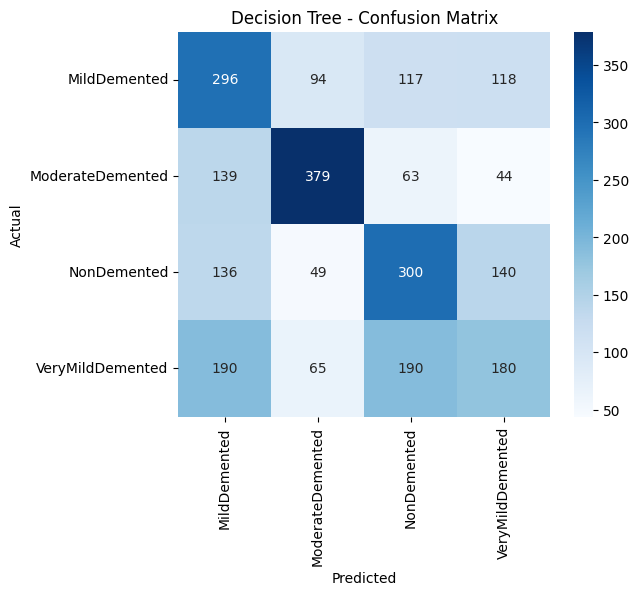

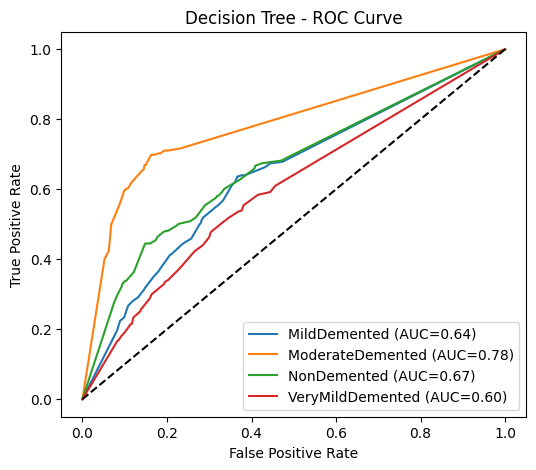

In [18]:

# DECISION TREE EVALUATION


dt_preds = dt_model.predict(X_test_scaled)
dt_probs = dt_model.predict_proba(X_test_scaled)

print("DECISION TREE CLASSIFICATION REPORT\n")
print(classification_report(y_test, dt_preds, target_names=le.classes_))

# Confusion Matrix
cm_dt = confusion_matrix(y_test, dt_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_dt, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Blues")
plt.title("Decision Tree - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
y_test_bin = label_binarize(y_test, classes=[0,1,2,3])

plt.figure(figsize=(6,5))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], dt_probs[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("Decision Tree - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


MLP CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    MildDemented       0.69      0.50      0.58       625
ModerateDemented       0.84      0.90      0.87       625
     NonDemented       0.55      0.69      0.61       625
VeryMildDemented       0.52      0.48      0.50       625

        accuracy                           0.64      2500
       macro avg       0.65      0.64      0.64      2500
    weighted avg       0.65      0.64      0.64      2500



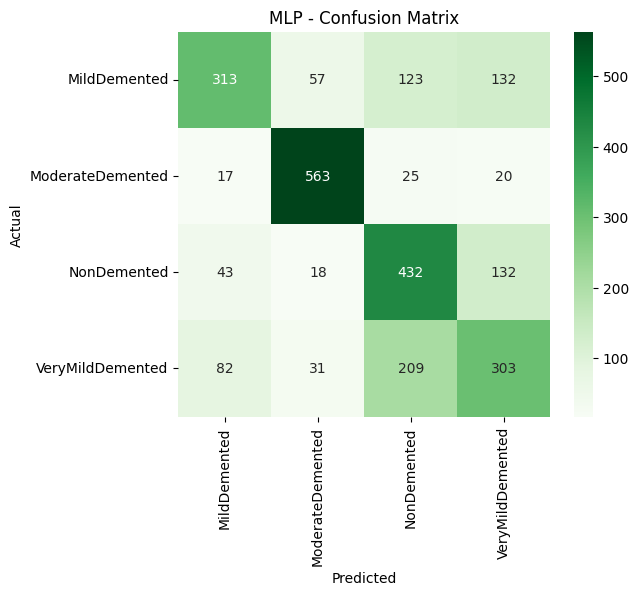

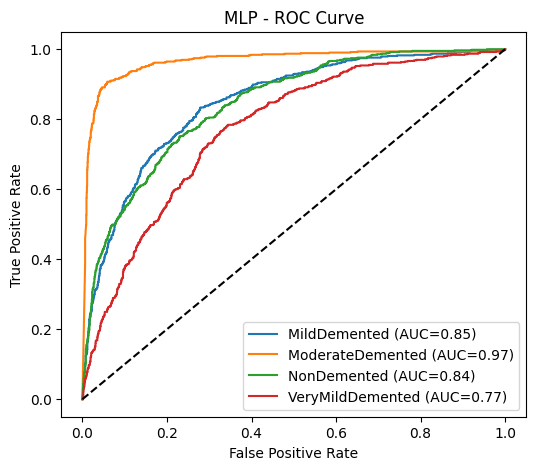

In [19]:

# MLP EVALUATION


mlp_preds = mlp_model.predict(X_test_scaled)
mlp_probs = mlp_model.predict_proba(X_test_scaled)

print("MLP CLASSIFICATION REPORT\n")
print(classification_report(y_test, mlp_preds, target_names=le.classes_))

# Confusion Matrix
cm_mlp = confusion_matrix(y_test, mlp_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_mlp, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Greens")
plt.title("MLP - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
plt.figure(figsize=(6,5))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], mlp_probs[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("MLP - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


79/79 ━━━━━━━━━━━━━━━━━━━━ 25s 315ms/step
CNN CLASSIFICATION REPORT

                  precision    recall  f1-score   support

    MildDemented       0.62      0.62      0.62       625
ModerateDemented       0.85      0.97      0.91       625
     NonDemented       0.59      0.70      0.64       625
VeryMildDemented       0.51      0.33      0.40       625

        accuracy                           0.66      2500
       macro avg       0.64      0.66      0.64      2500
    weighted avg       0.64      0.66      0.64      2500



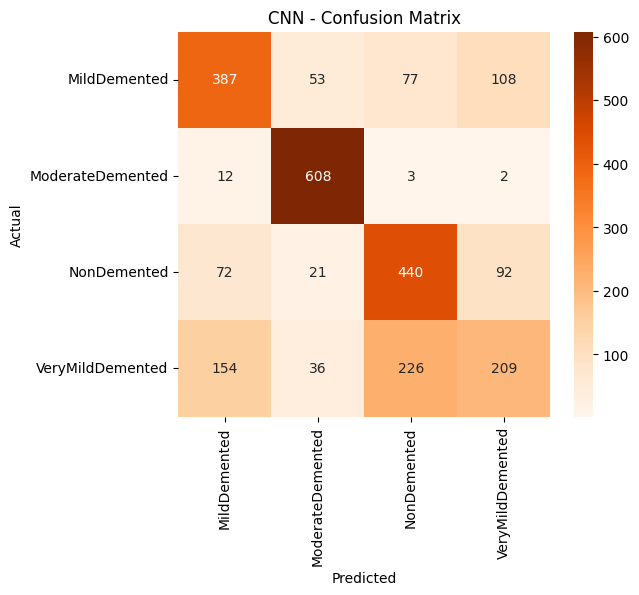

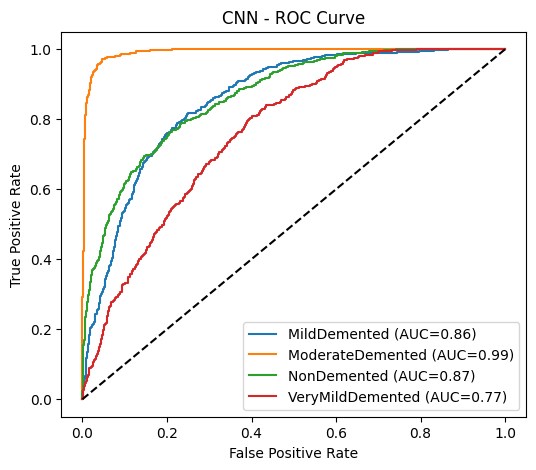

In [20]:

# CNN EVALUATION


cnn_probs = cnn_model.predict(X_test)
cnn_preds = np.argmax(cnn_probs, axis=1)

print("CNN CLASSIFICATION REPORT\n")
print(classification_report(y_test, cnn_preds, target_names=le.classes_))

# Confusion Matrix
cm_cnn = confusion_matrix(y_test, cnn_preds)

plt.figure(figsize=(6,5))
sns.heatmap(cm_cnn, annot=True, fmt="d",
            xticklabels=le.classes_,
            yticklabels=le.classes_,
            cmap="Oranges")
plt.title("CNN - Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

# ROC Curve
plt.figure(figsize=(6,5))
for i in range(4):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], cnn_probs[:, i])
    plt.plot(fpr, tpr, label=f"{le.classes_[i]} (AUC={auc(fpr,tpr):.2f})")

plt.plot([0,1],[0,1],'k--')
plt.title("CNN - ROC Curve")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.show()


## **MODEL COMPARISON**


MODEL COMPARISON TABLE

           Model  Accuracy  Macro F1-Score
0  Decision Tree    0.4620        0.460266
1            MLP    0.6444        0.640208
2            CNN    0.6576        0.642494


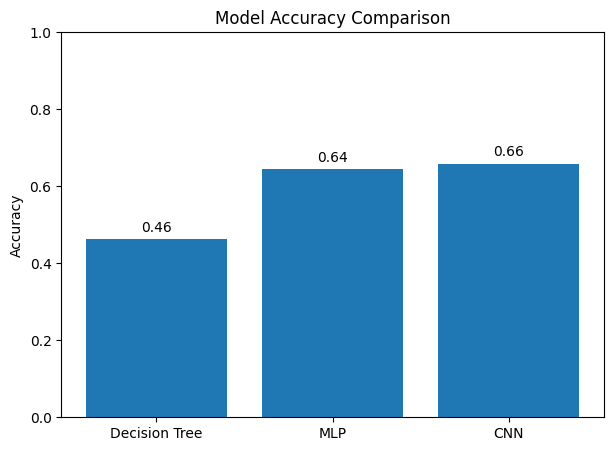

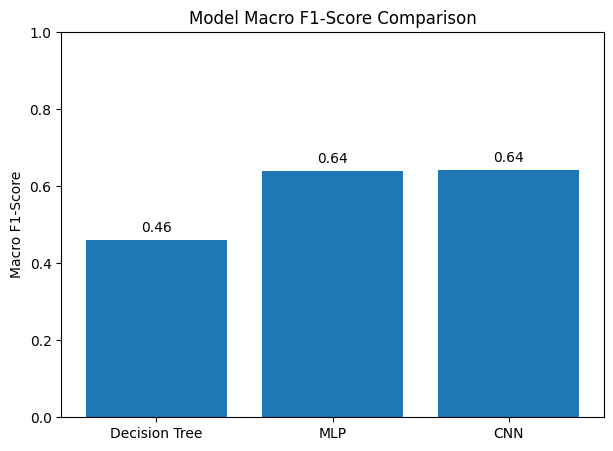

In [21]:
# MODEL COMPARISON: ACCURACY & F1-SCORE

from sklearn.metrics import accuracy_score, f1_score
import pandas as pd
import matplotlib.pyplot as plt

# Compute Accuracy
dt_accuracy = accuracy_score(y_test, dt_preds)
mlp_accuracy = accuracy_score(y_test, mlp_preds)
cnn_accuracy = accuracy_score(y_test, cnn_preds)

# Compute Macro F1-score
dt_f1 = f1_score(y_test, dt_preds, average='macro')
mlp_f1 = f1_score(y_test, mlp_preds, average='macro')
cnn_f1 = f1_score(y_test, cnn_preds, average='macro')

# Create comparison table
comparison_df = pd.DataFrame({
    "Model": ["Decision Tree", "MLP", "CNN"],
    "Accuracy": [dt_accuracy, mlp_accuracy, cnn_accuracy],
    "Macro F1-Score": [dt_f1, mlp_f1, cnn_f1]
})

print("\nMODEL COMPARISON TABLE\n")
print(comparison_df)

# Accuracy Plot
plt.figure(figsize=(7,5))
plt.bar(comparison_df["Model"], comparison_df["Accuracy"])
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.ylim(0,1)

for i, v in enumerate(comparison_df["Accuracy"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()

# Macro F1-score Plot
plt.figure(figsize=(7,5))
plt.bar(comparison_df["Model"], comparison_df["Macro F1-Score"])
plt.title("Model Macro F1-Score Comparison")
plt.ylabel("Macro F1-Score")
plt.ylim(0,1)

for i, v in enumerate(comparison_df["Macro F1-Score"]):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center')

plt.show()


## **SHAP + LIME (Explainable AI)**

In [ ]:

!pip install -q shap lime scikit-image

Running SHAP explanations...


/usr/local/lib/python3.12/dist-packages/shap/explainers/_deep/deep_tf.py:94: UserWarning: Your TensorFlow version is newer than 2.4.0 and so graph support has been removed in eager mode and some static graphs may not be supported. See PR #1483 for discussion.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(40, 128, 128, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(80, 128, 128, 1))']
  warnings.warn(msg)
/usr/local/lib/python3.12/dist-packages/keras/src/models/functional.py:241: UserWarning: The structure of `inputs` doesn't match the expected structure.
Expected: keras_tensor_8
Received: inputs=['Tensor(shape=(4, 128, 

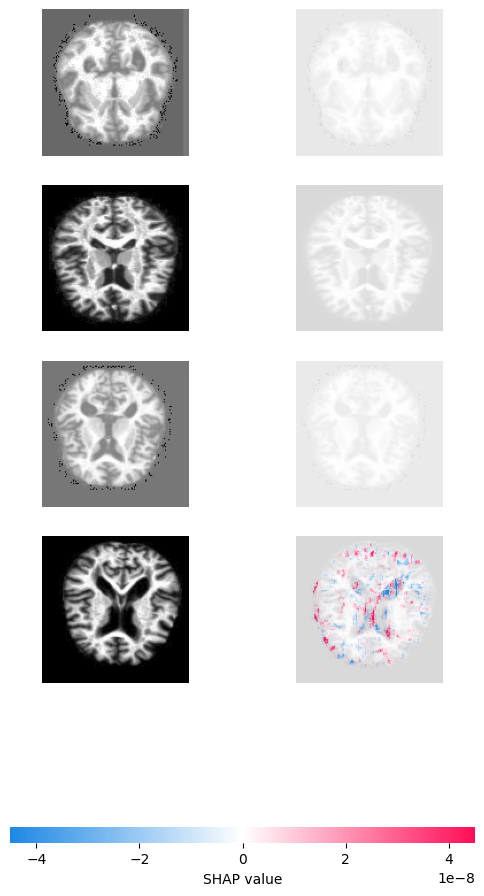

Running LIME explanation...


  0%|          | 0/1000 [00:00<?, ?it/s]

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 173ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 153ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 178ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 187ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 116ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 136ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 128ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 104ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 110ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 108ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 105ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 107ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 106ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 115ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 

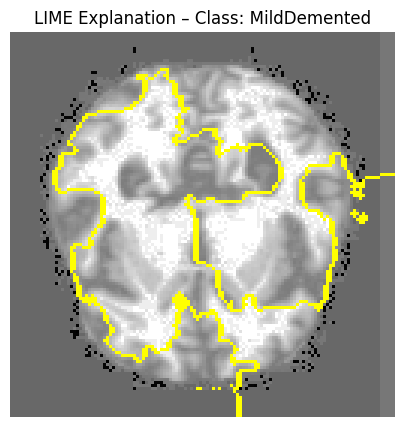

In [23]:
# SHAP + LIME (Explainable AI)
import shap
import lime
import lime.lime_image
import numpy as np
import matplotlib.pyplot as plt
from skimage.segmentation import mark_boundaries

# SHAP (CNN) – GLOBAL & LOCAL

print("Running SHAP explanations...")

# Use small background set for stability
background = X_train[np.random.choice(X_train.shape[0], 40, replace=False)]
test_samples = X_test[:4]

explainer = shap.DeepExplainer(cnn_model, background)
shap_values = explainer.shap_values(test_samples)

shap.image_plot(shap_values, test_samples)


# LIME (CNN) – LOCAL EXPLANATION

print("Running LIME explanation...")

explainer_lime = lime.lime_image.LimeImageExplainer()

# Select one image
idx = 0
image = X_test[idx].squeeze()

# LIME requires 3-channel images → replicate grayscale
image_rgb = np.stack([image, image, image], axis=-1)

def cnn_predict_lime(images):
    images = np.mean(images, axis=-1)          # Convert back to grayscale
    images = images.reshape(-1, 128, 128, 1)
    return cnn_model.predict(images)

explanation = explainer_lime.explain_instance(
    image_rgb,
    cnn_predict_lime,
    top_labels=1,
    hide_color=0,
    num_samples=1000
)

predicted_class = np.argmax(cnn_model.predict(X_test[idx:idx+1]))

lime_image, mask = explanation.get_image_and_mask(
    label=predicted_class,
    positive_only=True,
    num_features=10,
    hide_rest=False
)

plt.figure(figsize=(5,5))
plt.imshow(mark_boundaries(lime_image, mask))
plt.title(f"LIME Explanation – Class: {le.inverse_transform([predicted_class])[0]}")
plt.axis("off")
plt.show()